# IDW temporal de janelas climaticas

Graficos de barras e interpolacao IDW para PRECTOTCORR, PW, RH2M, GWETTOP, EVLAND e EVPTRNS.


In [7]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.spatial import cKDTree
from shapely.geometry import Point
from geobr import read_state

pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', '{:,.4f}'.format)
sns.set_theme(style='whitegrid', context='notebook')

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_FINAL = PROJECT_ROOT / 'data' / 'processed' / 'dataset_final.parquet'
if not DATA_FINAL.exists():
    raise FileNotFoundError(f'Arquivo nao encontrado: {DATA_FINAL}')

dataset = pd.read_parquet(DATA_FINAL).copy()

ANALISES_IDW = [
    {'nome': 'PRECTOTCORR', 'janela': 'dec32_ano1 a dec35_ano1', 'coluna_soma': 'PRECTOTCORR_soma_dec32_dec35_ano1', 'colunas': ['PRECTOTCORR_dec32_ano1', 'PRECTOTCORR_dec33_ano1', 'PRECTOTCORR_dec34_ano1', 'PRECTOTCORR_dec35_ano1'], 'cor_barras': '#2f6f73', 'label_barra': 'PRECTOTCORR acumulado'},
    {'nome': 'PW', 'janela': 'dec2_ano2 a dec5_ano2', 'coluna_soma': 'PW_soma_dec2_dec5_ano2', 'colunas': ['PW_dec2_ano2', 'PW_dec3_ano2', 'PW_dec4_ano2', 'PW_dec5_ano2'], 'cor_barras': '#586f9f', 'label_barra': 'PW acumulado'},
    {'nome': 'RH2M', 'janela': 'dec34_ano1 a dec35_ano1', 'coluna_soma': 'RH2M_soma_dec34_dec35_ano1', 'colunas': ['RH2M_dec34_ano1', 'RH2M_dec35_ano1'], 'cor_barras': '#4f8f6f', 'label_barra': 'RH2M acumulado'},
    {'nome': 'GWETTOP', 'janela': 'dec35_ano1', 'coluna_soma': 'GWETTOP_soma_dec35_ano1', 'colunas': ['GWETTOP_dec35_ano1'], 'cor_barras': '#8a6f3f', 'label_barra': 'GWETTOP'},
    {'nome': 'EVLAND', 'janela': 'dec35_ano1 a dec1_ano2', 'coluna_soma': 'EVLAND_soma_dec35_ano1_dec1_ano2', 'colunas': ['EVLAND_dec35_ano1', 'EVLAND_dec36_ano1', 'EVLAND_dec1_ano2'], 'cor_barras': '#a05858', 'label_barra': 'EVLAND acumulado'},
    {'nome': 'EVPTRNS', 'janela': 'dec35_ano1 a dec4_ano2', 'coluna_soma': 'EVPTRNS_soma_dec35_ano1_dec4_ano2', 'colunas': ['EVPTRNS_dec35_ano1', 'EVPTRNS_dec36_ano1', 'EVPTRNS_dec1_ano2', 'EVPTRNS_dec2_ano2', 'EVPTRNS_dec3_ano2', 'EVPTRNS_dec4_ano2'], 'cor_barras': '#7a6aa8', 'label_barra': 'EVPTRNS acumulado'},
]


def preparar_janela_decendios(nome_saida, colunas_janela):
    colunas_base = ['cod_ibge', 'municipio', 'ano', 'mesorregiao', 'latitude', 'longitude']
    colunas_obrigatorias = colunas_base + colunas_janela
    faltantes = [col for col in colunas_obrigatorias if col not in dataset.columns]
    if faltantes:
        raise ValueError(f'Colunas nao encontradas para {nome_saida}: {faltantes}')

    dados = dataset[colunas_obrigatorias].copy()
    dados['ano'] = pd.to_numeric(dados['ano'], errors='coerce').astype('Int64')
    dados['latitude'] = pd.to_numeric(dados['latitude'], errors='coerce')
    dados['longitude'] = pd.to_numeric(dados['longitude'], errors='coerce')
    for col in colunas_janela:
        dados[col] = pd.to_numeric(dados[col], errors='coerce')

    dados[nome_saida] = dados[colunas_janela].sum(axis=1, min_count=1)
    return dados


dados_por_analise = {}
for analise in ANALISES_IDW:
    dados = preparar_janela_decendios(analise['coluna_soma'], analise['colunas'])
    dados_por_analise[analise['nome']] = dados
    display(dados.head())
    print(f"{analise['nome']} ({analise['janela']}) - municipios: {dados['municipio'].nunique()}")

print(f"Anos: {sorted(next(iter(dados_por_analise.values()))['ano'].dropna().unique().tolist())}")


,cod_ibge,municipio,ano,mesorregiao,latitude,longitude,PRECTOTCORR_dec32_ano1,PRECTOTCORR_dec33_ano1,PRECTOTCORR_dec34_ano1,PRECTOTCORR_dec35_ano1,PRECTOTCORR_soma_dec32_dec35_ano1
0,4100103,Abatiá (PR),2018,Norte Pioneiro Paranaense,-23.2974,-50.3384,49.6500,59.9400,14.3700,41.5600,165.5200
1,4100103,Abatiá (PR),2019,Norte Pioneiro Paranaense,-23.2974,-50.3384,40.3300,62.8900,11.0700,29.3000,143.5900
2,4100103,Abatiá (PR),2020,Norte Pioneiro Paranaense,-23.2974,-50.3384,128.0700,69.0800,29.1200,117.6600,343.9300
3,4100103,Abatiá (PR),2021,Norte Pioneiro Paranaense,-23.2974,-50.3384,33.3900,12.0700,44.4200,52.3800,142.2600
4,4100103,Abatiá (PR),2022,Norte Pioneiro Paranaense,-23.2974,-50.3384,33.6400,43.4600,12.9000,24.8300,114.8300


PRECTOTCORR (dec32_ano1 a dec35_ano1) - municipios: 399


,cod_ibge,municipio,ano,mesorregiao,latitude,longitude,PW_dec2_ano2,PW_dec3_ano2,PW_dec4_ano2,PW_dec5_ano2,PW_soma_dec2_dec5_ano2
0,4100103,Abatiá (PR),2018,Norte Pioneiro Paranaense,-23.2974,-50.3384,4.5790,4.1664,2.8860,4.0710,15.7024
1,4100103,Abatiá (PR),2019,Norte Pioneiro Paranaense,-23.2974,-50.3384,4.0820,3.7236,3.4400,3.7080,14.9536
2,4100103,Abatiá (PR),2020,Norte Pioneiro Paranaense,-23.2974,-50.3384,4.3280,3.7482,4.6660,3.8790,16.6212
3,4100103,Abatiá (PR),2021,Norte Pioneiro Paranaense,-23.2974,-50.3384,4.4560,4.3336,2.8790,3.0000,14.6686
4,4100103,Abatiá (PR),2022,Norte Pioneiro Paranaense,-23.2974,-50.3384,4.1020,4.1391,3.7260,2.9490,14.9161


PW (dec2_ano2 a dec5_ano2) - municipios: 399


,cod_ibge,municipio,ano,mesorregiao,latitude,longitude,RH2M_dec34_ano1,RH2M_dec35_ano1,RH2M_soma_dec34_dec35_ano1
0,4100103,Abatiá (PR),2018,Norte Pioneiro Paranaense,-23.2974,-50.3384,79.3870,72.0460,151.4330
1,4100103,Abatiá (PR),2019,Norte Pioneiro Paranaense,-23.2974,-50.3384,71.3170,69.5680,140.8850
2,4100103,Abatiá (PR),2020,Norte Pioneiro Paranaense,-23.2974,-50.3384,73.4050,84.1530,157.5580
3,4100103,Abatiá (PR),2021,Norte Pioneiro Paranaense,-23.2974,-50.3384,71.9860,74.6040,146.5900
4,4100103,Abatiá (PR),2022,Norte Pioneiro Paranaense,-23.2974,-50.3384,58.0000,66.0230,124.0230


...

GWETTOP (dec35_ano1) - municipios: 399


,cod_ibge,municipio,ano,mesorregiao,latitude,longitude,EVLAND_dec35_ano1,EVLAND_dec36_ano1,EVLAND_dec1_ano2,EVLAND_soma_dec35_ano1_dec1_ano2
0,4100103,Abatiá (PR),2018,Norte Pioneiro Paranaense,-23.2974,-50.3384,4.5660,4.3591,4.8470,13.7721
1,4100103,Abatiá (PR),2019,Norte Pioneiro Paranaense,-23.2974,-50.3384,4.3740,4.4164,3.8810,12.6714
2,4100103,Abatiá (PR),2020,Norte Pioneiro Paranaense,-23.2974,-50.3384,3.9050,5.5182,4.3150,13.7382
3,4100103,Abatiá (PR),2021,Norte Pioneiro Paranaense,-23.2974,-50.3384,3.6310,3.3527,4.1380,11.1217
4,4100103,Abatiá (PR),2022,Norte Pioneiro Paranaense,-23.2974,-50.3384,3.1510,2.7409,3.7510,9.6429


EVLAND (dec35_ano1 a dec1_ano2) - municipios: 399


,cod_ibge,municipio,ano,mesorregiao,latitude,longitude,EVPTRNS_dec35_ano1,EVPTRNS_dec36_ano1,EVPTRNS_dec1_ano2,EVPTRNS_dec2_ano2,EVPTRNS_dec3_ano2,EVPTRNS_dec4_ano2,EVPTRNS_soma_dec35_ano1_dec4_ano2
0,4100103,Abatiá (PR),2018,Norte Pioneiro Paranaense,-23.2974,-50.3384,5.3110,4.6518,6.4850,2.9390,6.7300,9.7270,35.8438
1,4100103,Abatiá (PR),2019,Norte Pioneiro Paranaense,-23.2974,-50.3384,5.0080,5.1618,4.0730,6.8280,5.4682,2.6770,29.2160
2,4100103,Abatiá (PR),2020,Norte Pioneiro Paranaense,-23.2974,-50.3384,4.0630,8.5355,4.5450,6.6180,3.4000,4.5290,31.6905
3,4100103,Abatiá (PR),2021,Norte Pioneiro Paranaense,-23.2974,-50.3384,2.7360,2.2927,3.7850,2.6870,4.0309,7.8980,23.4296
4,4100103,Abatiá (PR),2022,Norte Pioneiro Paranaense,-23.2974,-50.3384,1.8460,1.4909,2.9340,3.3400,3.2055,6.3100,19.1264


EVPTRNS (dec35_ano1 a dec4_ano2) - municipios: 399
Anos: [2018, 2019, 2020, 2021, 2022, 2023, 2024]


,ano,soma_total,media_municipal,n_municipios
0,2018,"66,018.3400",165.4595,399
1,2019,"51,017.4400",127.8633,399
2,2020,"111,019.4000",278.2441,399
3,2021,"79,439.8500",199.0974,399
4,2022,"29,224.3700",73.2440,399
5,2023,"74,722.4700",187.2744,399
6,2024,"77,253.9400",193.6189,399


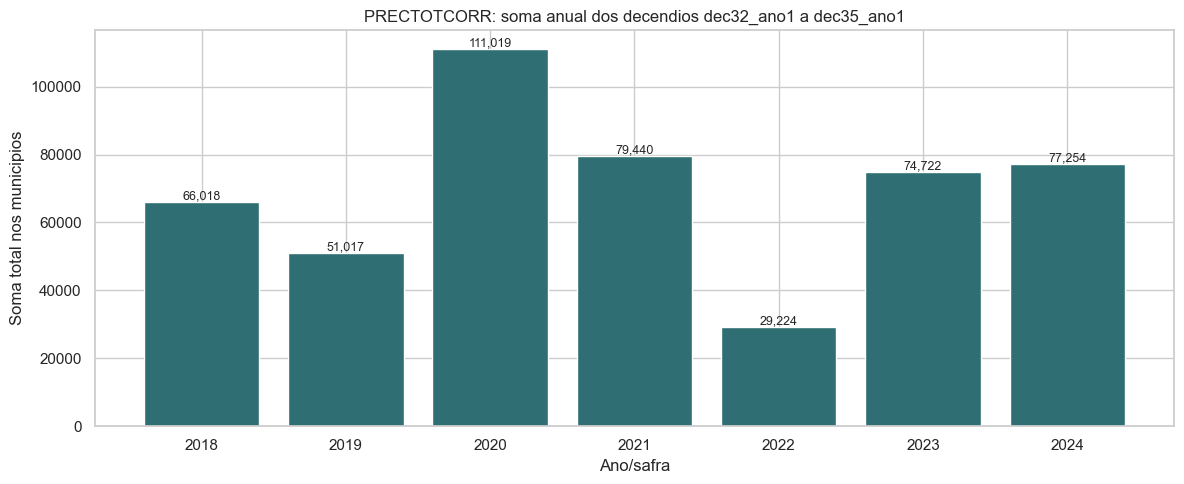

,ano,soma_total,media_municipal,n_municipios
0,2018,"6,221.2454",15.5921,399
1,2019,"6,031.3011",15.1160,399
2,2020,"6,499.2069",16.2887,399
3,2021,"5,925.9616",14.8520,399
4,2022,"5,596.1165",14.0254,399
5,2023,"6,461.8175",16.1950,399
6,2024,"6,451.5067",16.1692,399


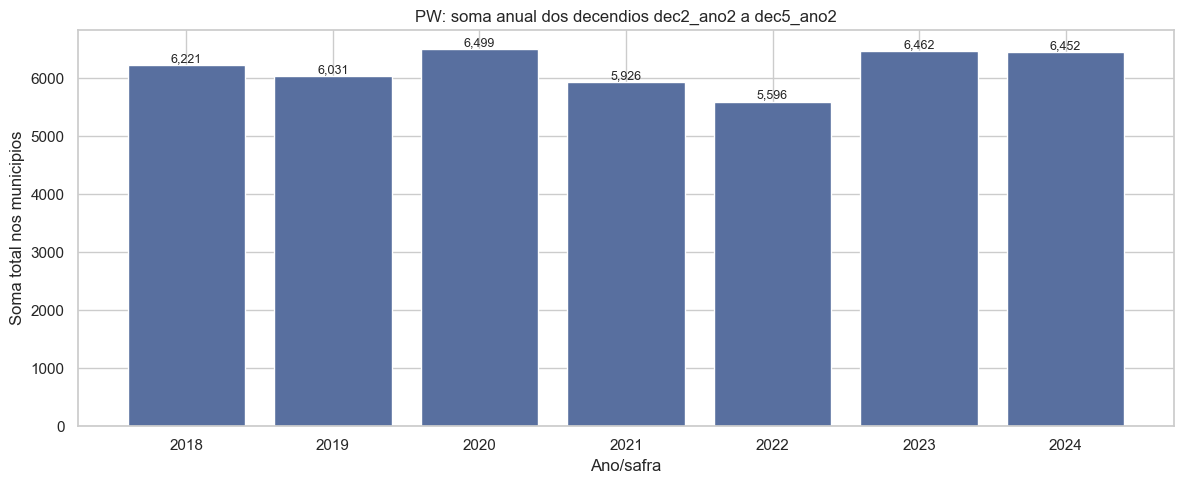

,ano,soma_total,media_municipal,n_municipios
0,2018,"59,522.5330",149.1793,399
1,2019,"53,979.7150",135.2875,399
2,2020,"62,670.3930",157.0687,399
3,2021,"59,795.1640",149.8626,399
4,2022,"45,966.6470",115.2046,399
5,2023,"63,330.2360",158.7224,399
6,2024,"62,123.6120",155.6983,399


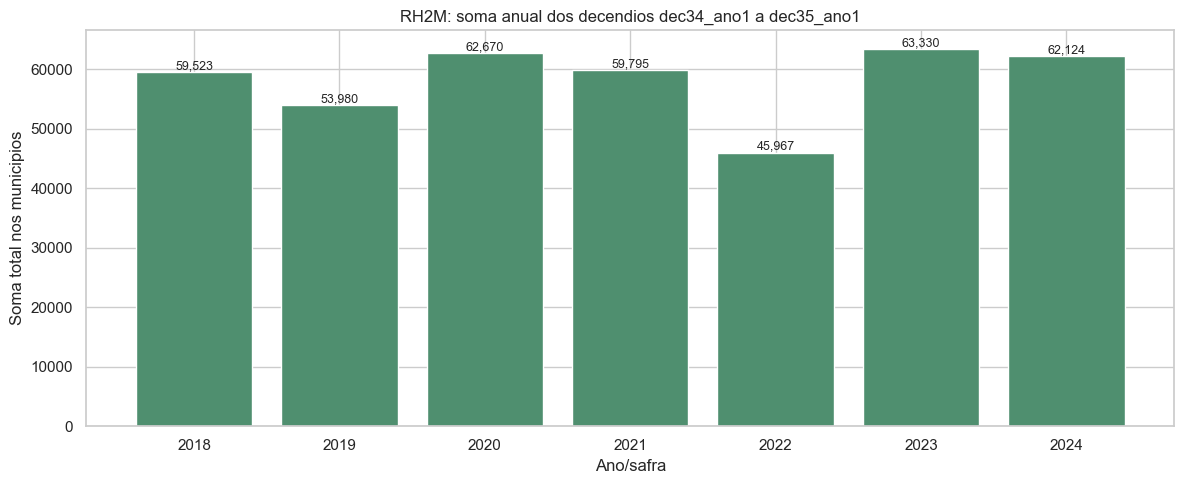

,ano,soma_total,media_municipal,n_municipios
0,2018,255.9930,0.6416,399
1,2019,248.0180,0.6216,399
2,2020,291.1980,0.7298,399
3,2021,259.0260,0.6492,399
4,2022,202.1130,0.5065,399
5,2023,281.6680,0.7059,399
6,2024,268.0390,0.6718,399


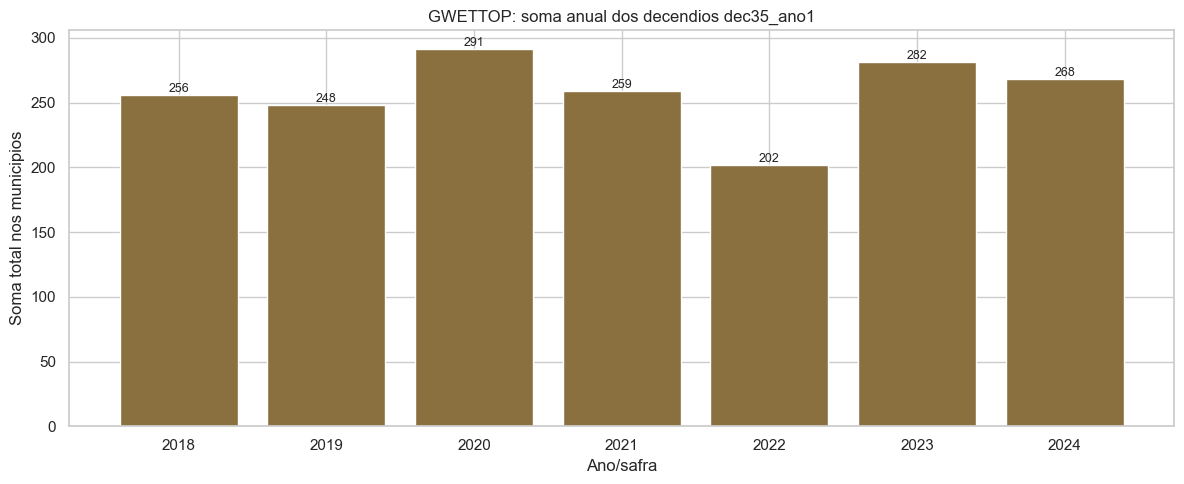

,ano,soma_total,media_municipal,n_municipios
0,2018,"5,956.3256",14.9281,399
1,2019,"5,046.8533",12.6488,399
2,2020,"5,885.4545",14.7505,399
3,2021,"5,280.9871",13.2356,399
4,2022,"3,191.0423",7.9976,399
5,2023,"5,574.0678",13.9701,399
6,2024,"5,646.4122",14.1514,399


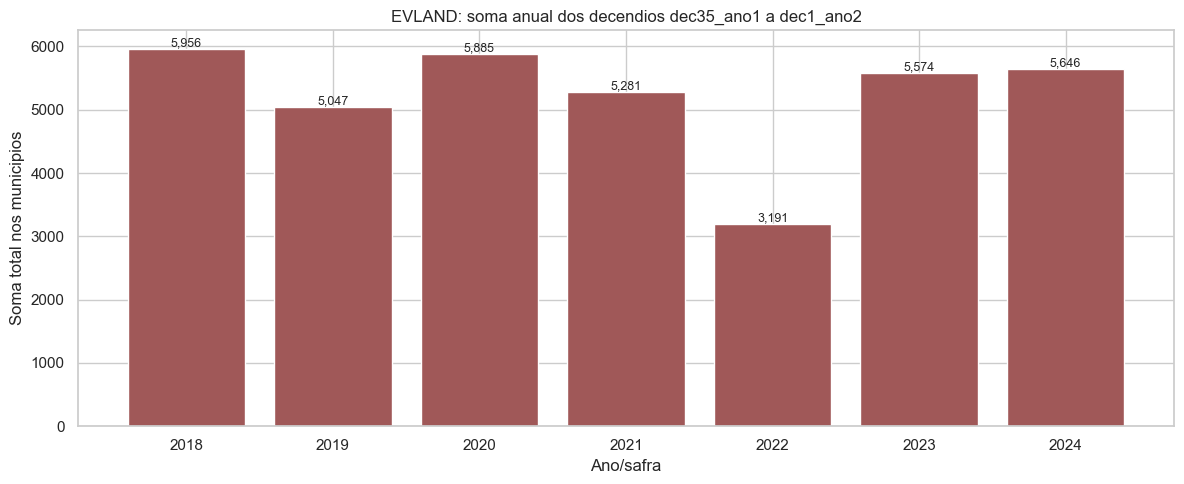

,ano,soma_total,media_municipal,n_municipios
0,2018,"15,787.2352",39.5670,399
1,2019,"12,495.3669",31.3167,399
2,2020,"14,975.7814",37.5333,399
3,2021,"12,711.2369",31.8577,399
4,2022,"6,334.3101",15.8755,399
5,2023,"14,196.9588",35.5814,399
6,2024,"13,114.0136",32.8672,399


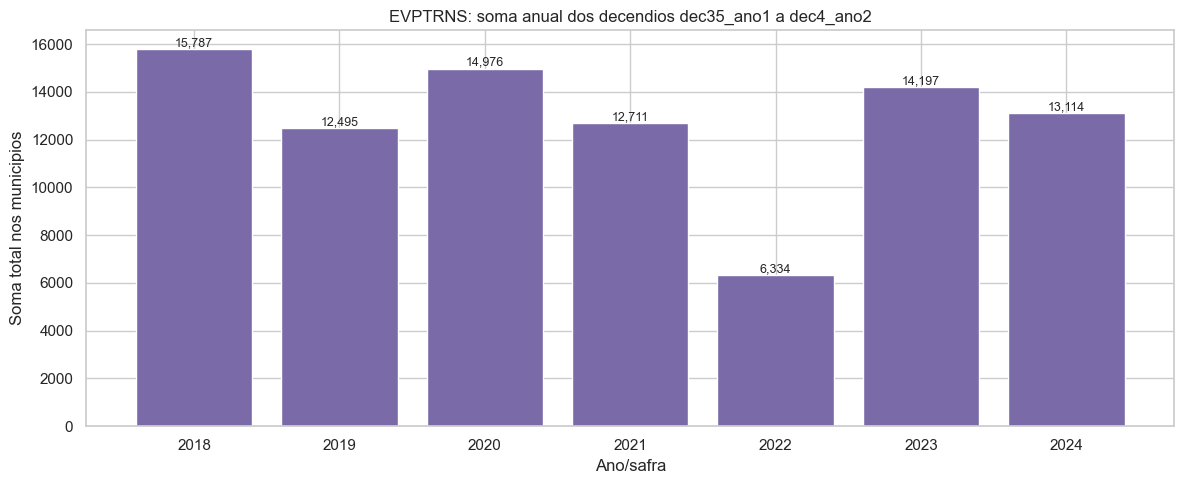

In [8]:
def grafico_barras_soma_anual(dados, coluna_soma, titulo, cor='#2f6f73'):
    agregado_anual = (
        dados
        .dropna(subset=['ano', coluna_soma])
        .groupby('ano', as_index=False)
        .agg(
            soma_total=(coluna_soma, 'sum'),
            media_municipal=(coluna_soma, 'mean'),
            n_municipios=('municipio', 'nunique')
        )
        .sort_values('ano')
    )

    display(agregado_anual)

    plt.figure(figsize=(12, 5))
    bars = plt.bar(agregado_anual['ano'].astype(str), agregado_anual['soma_total'], color=cor, edgecolor='white')

    for bar, valor in zip(bars, agregado_anual['soma_total']):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{valor:,.0f}', ha='center', va='bottom', fontsize=9)

    plt.title(titulo)
    plt.xlabel('Ano/safra')
    plt.ylabel('Soma total nos municipios')
    plt.tight_layout()
    plt.show()
    return agregado_anual


agregados_anuais = {}
for analise in ANALISES_IDW:
    agregados_anuais[analise['nome']] = grafico_barras_soma_anual(
        dados_por_analise[analise['nome']],
        analise['coluna_soma'],
        f"{analise['nome']}: soma anual dos decendios {analise['janela']}",
        cor=analise['cor_barras']
    )


Poligono usado: geobr.read_state(PR)
Grade IDW valida: 57,348 pontos dentro do Parana


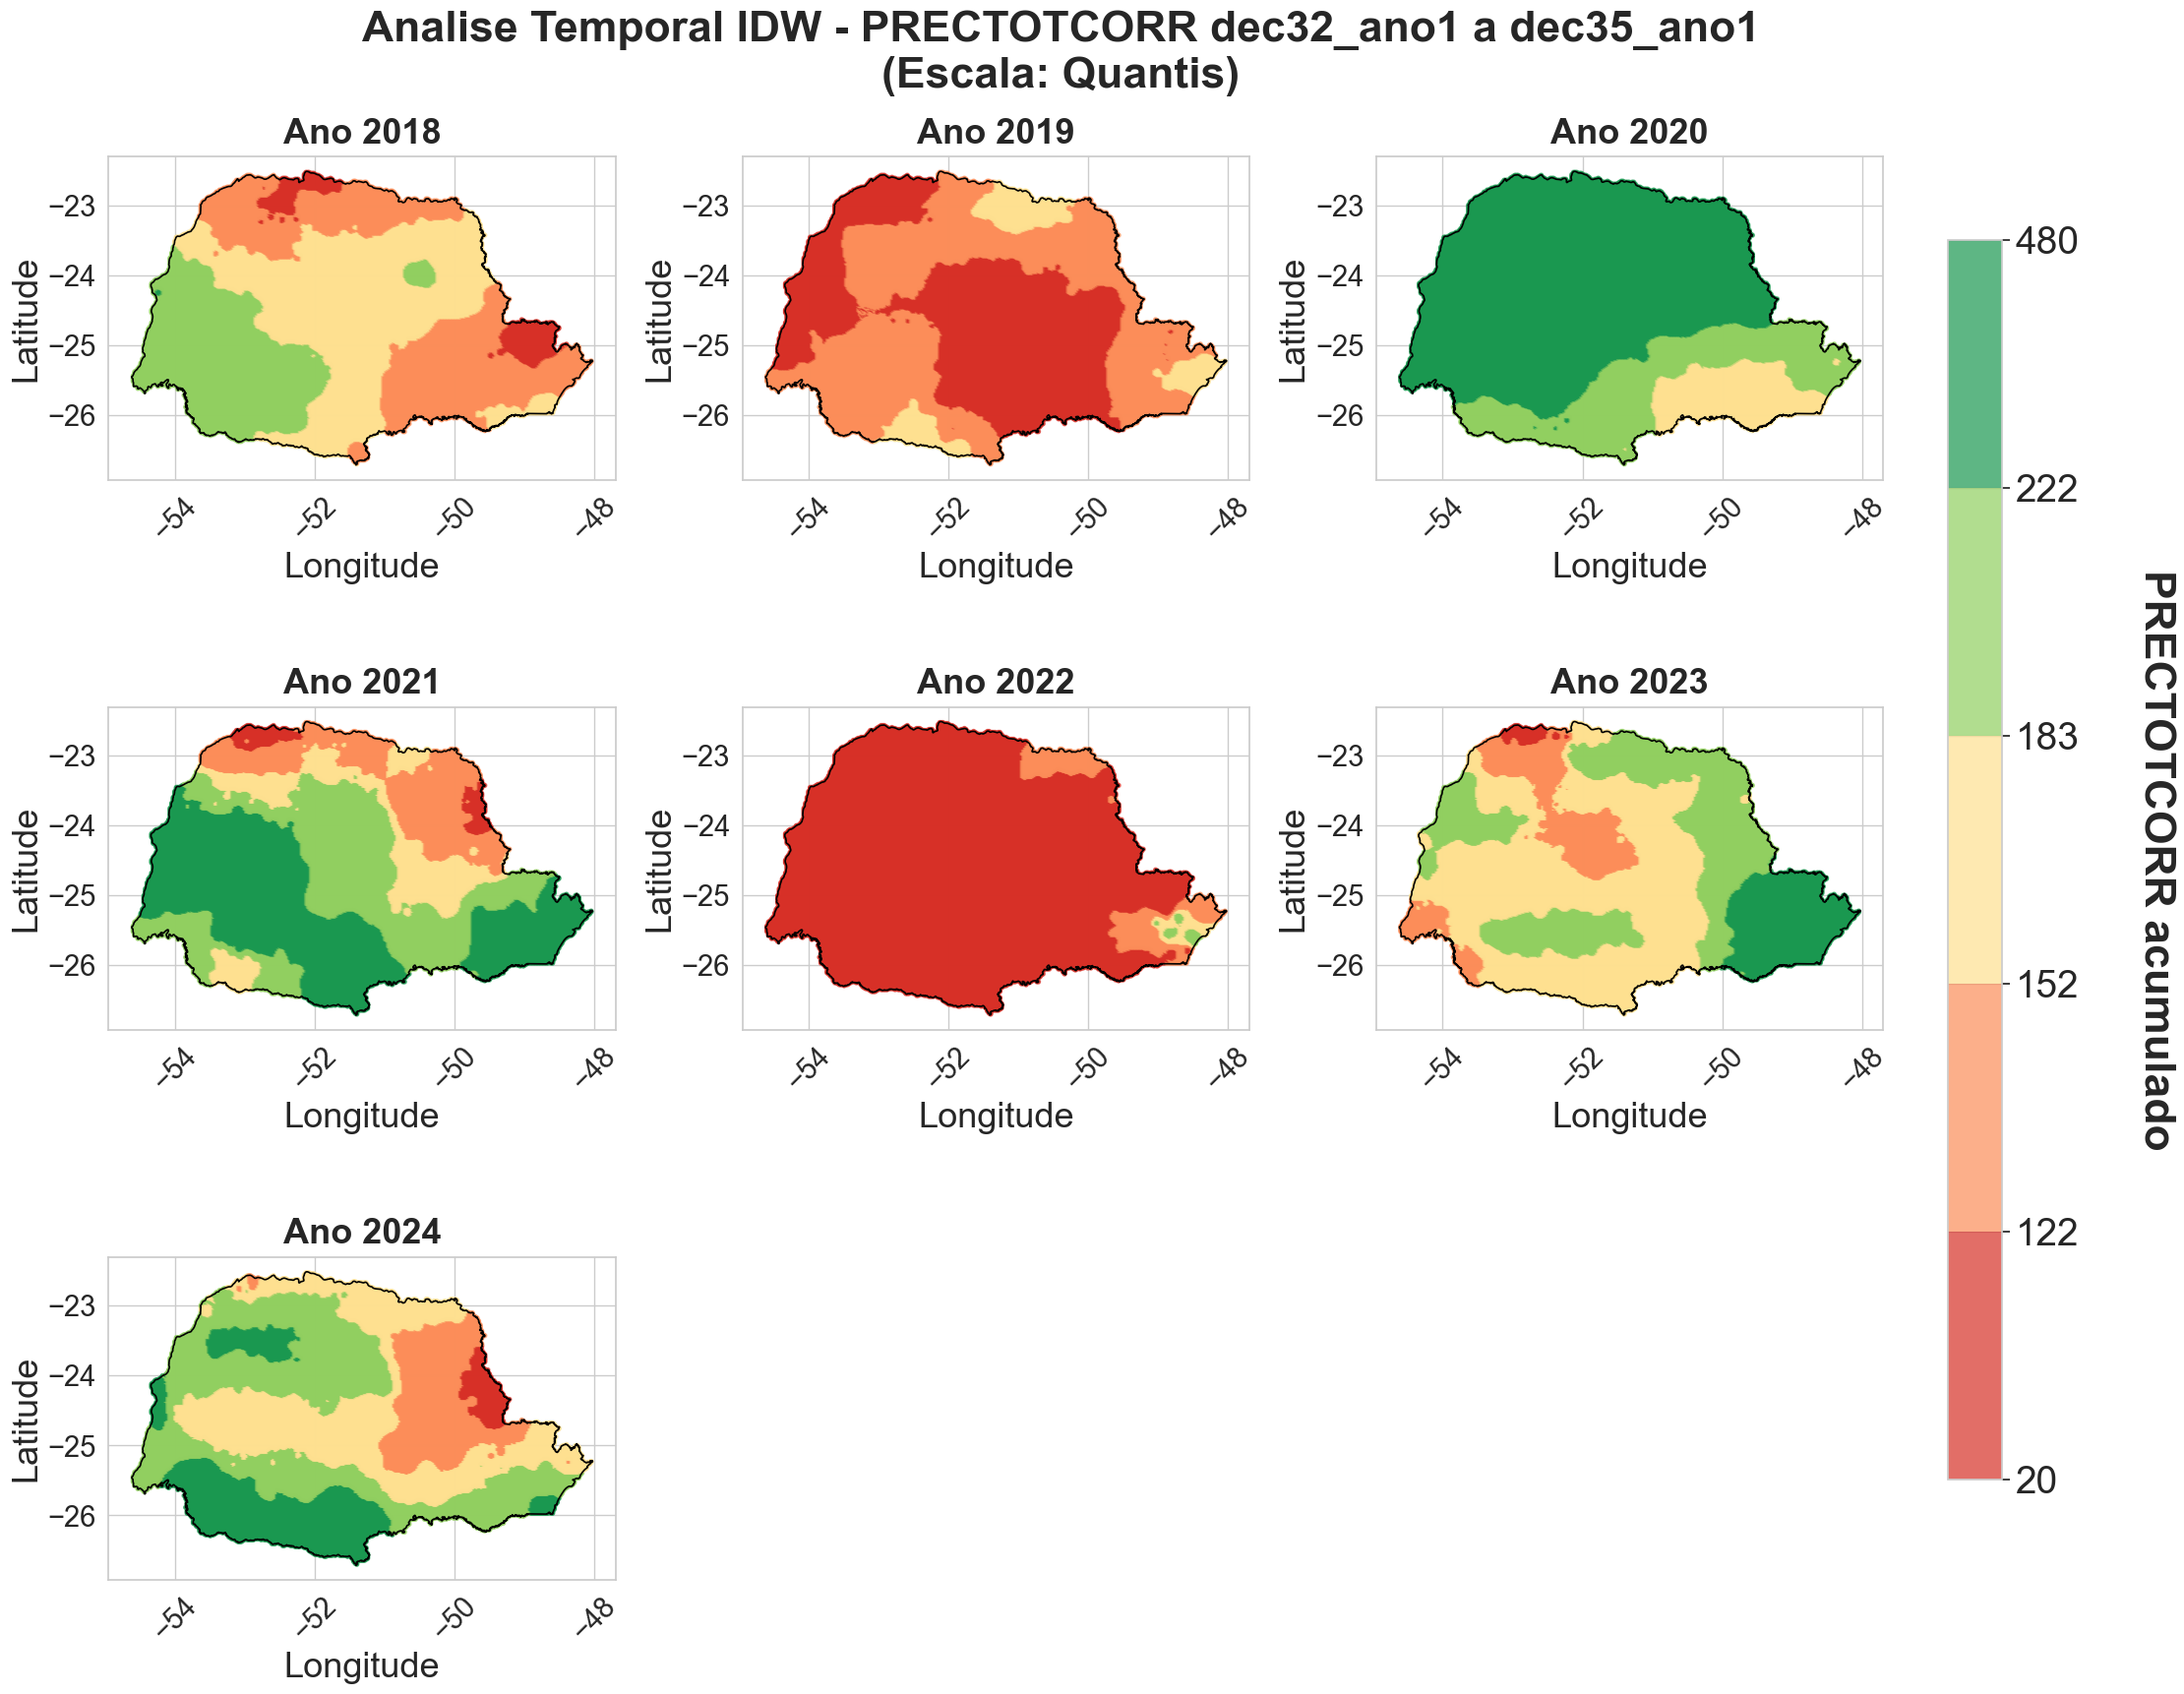

PRECTOTCORR dec32_ano1 a dec35_ano1 - anos interpolados: [2018, 2019, 2020, 2021, 2022, 2023, 2024]
PRECTOTCORR dec32_ano1 a dec35_ano1 - municipios por ano: {2018: 399, 2019: 399, 2020: 399, 2021: 399, 2022: 399, 2023: 399, 2024: 399}


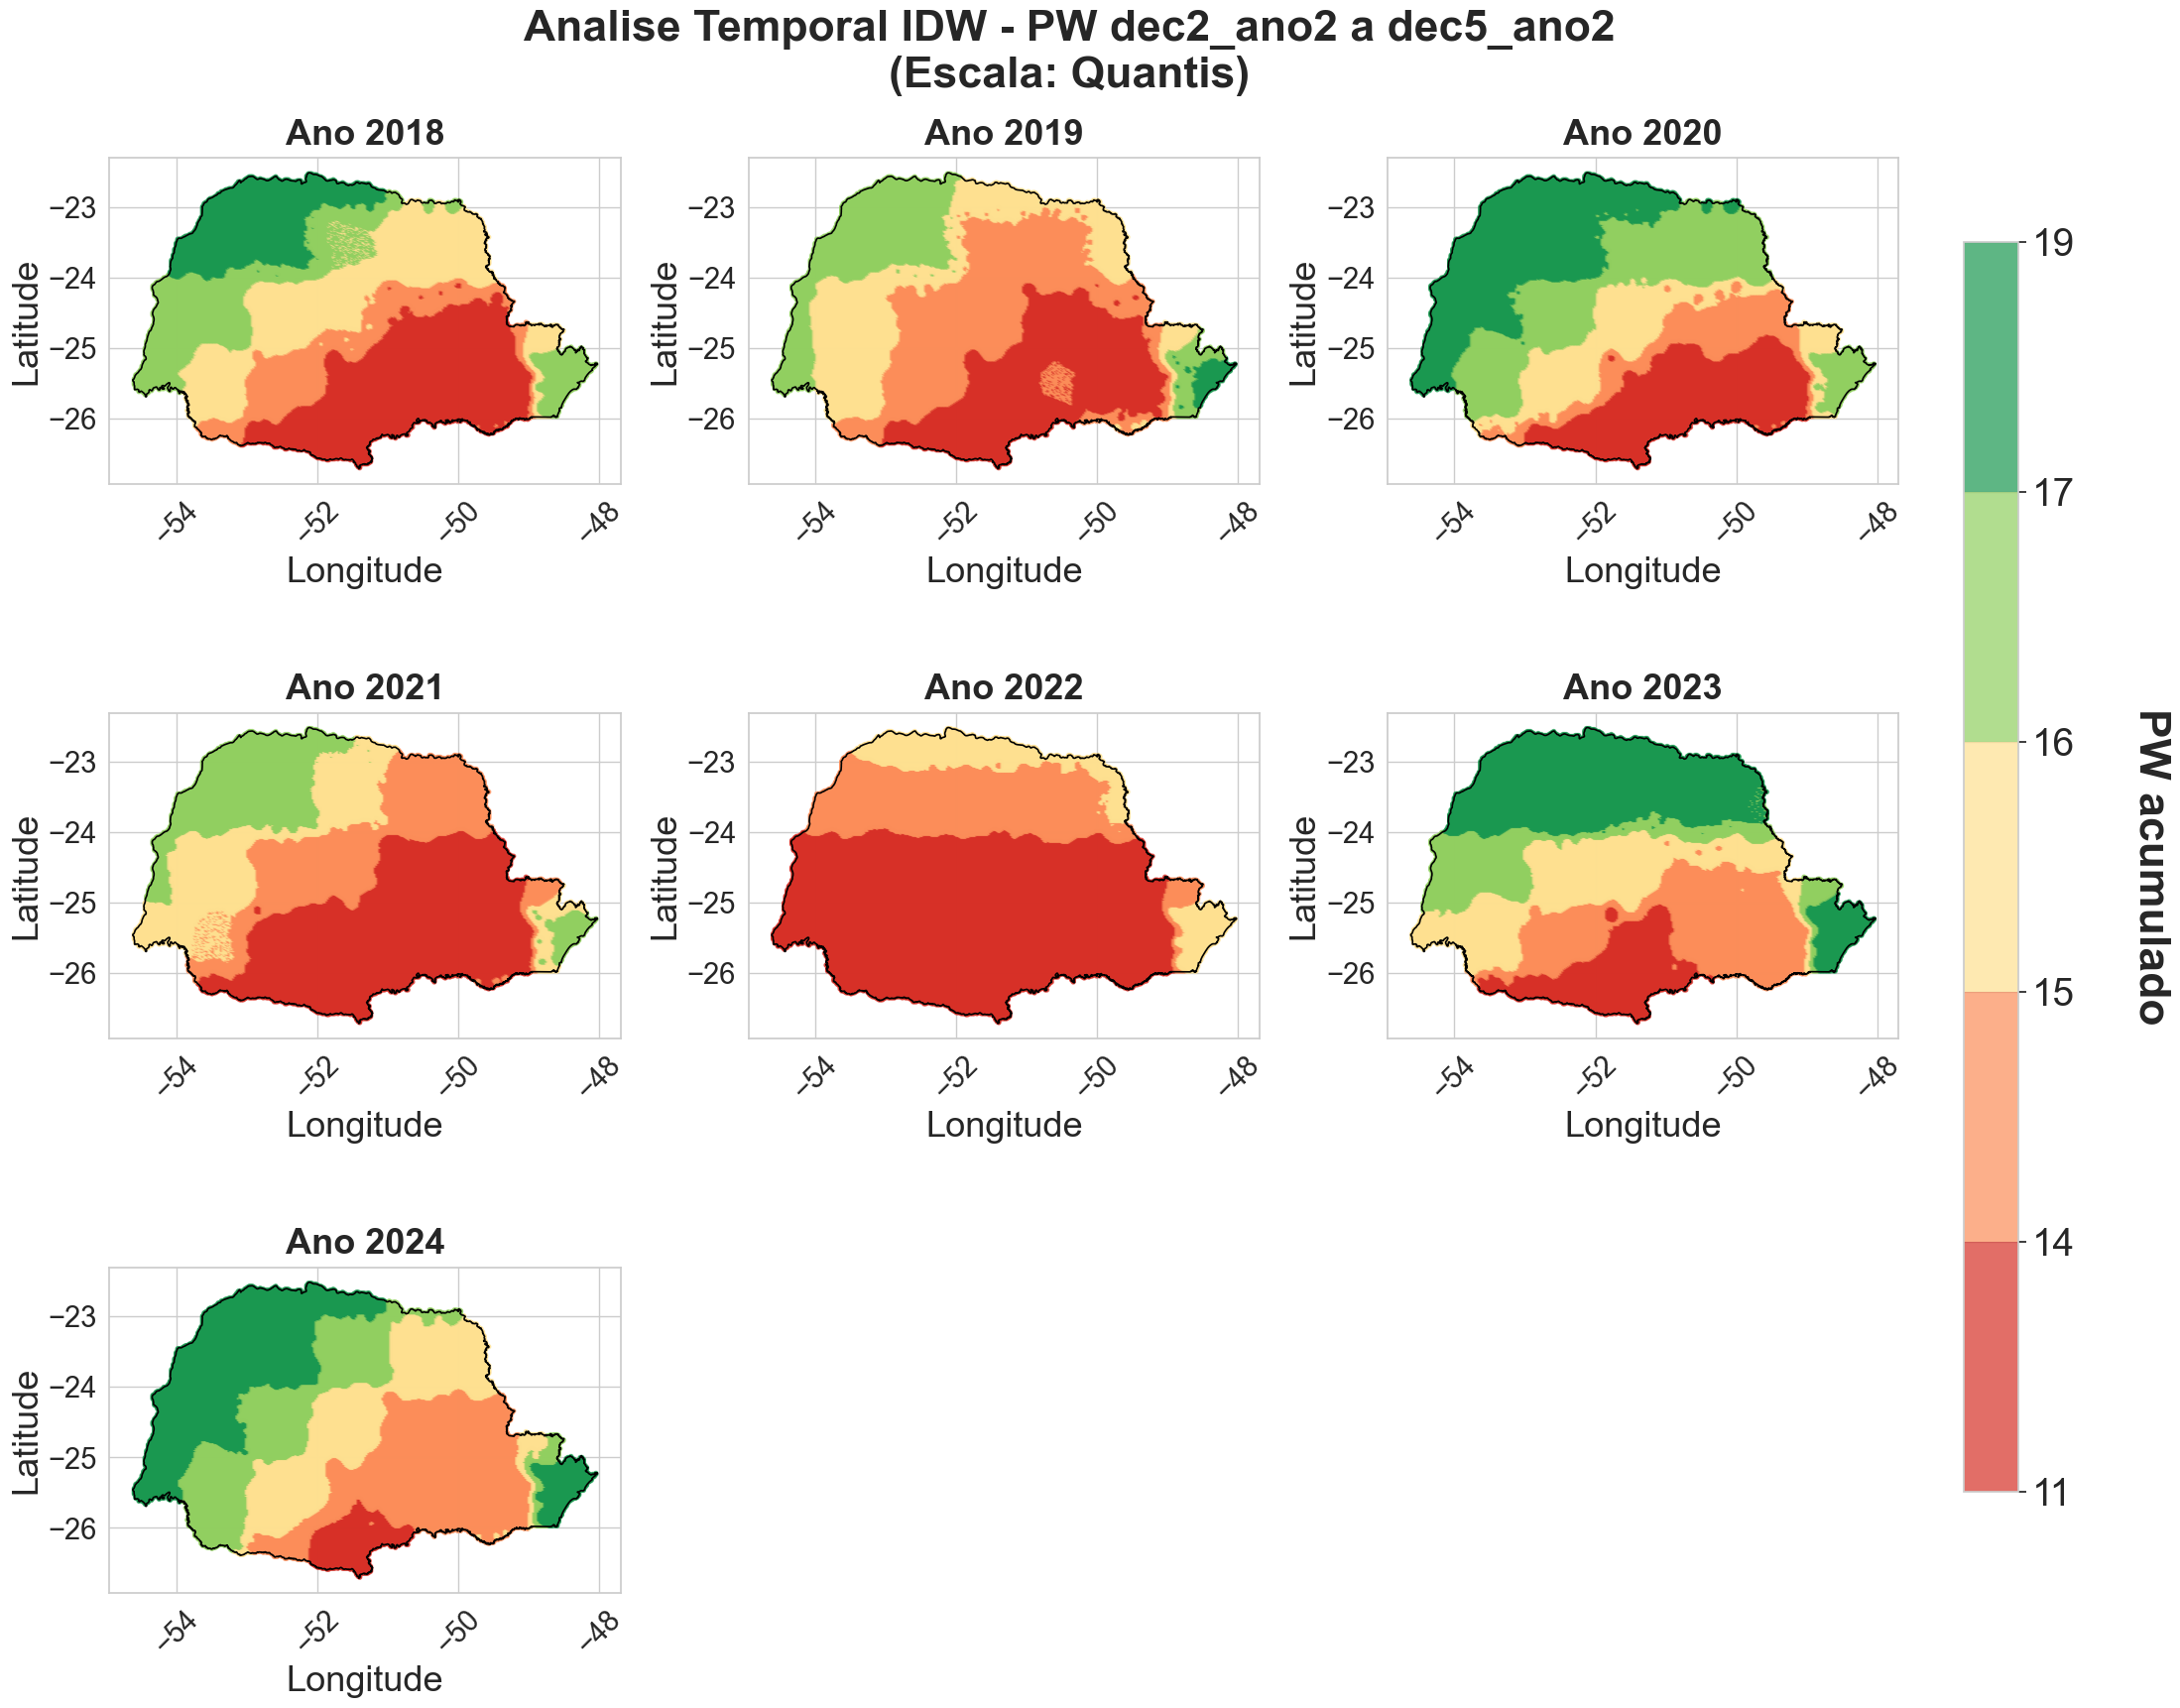

PW dec2_ano2 a dec5_ano2 - anos interpolados: [2018, 2019, 2020, 2021, 2022, 2023, 2024]
PW dec2_ano2 a dec5_ano2 - municipios por ano: {2018: 399, 2019: 399, 2020: 399, 2021: 399, 2022: 399, 2023: 399, 2024: 399}


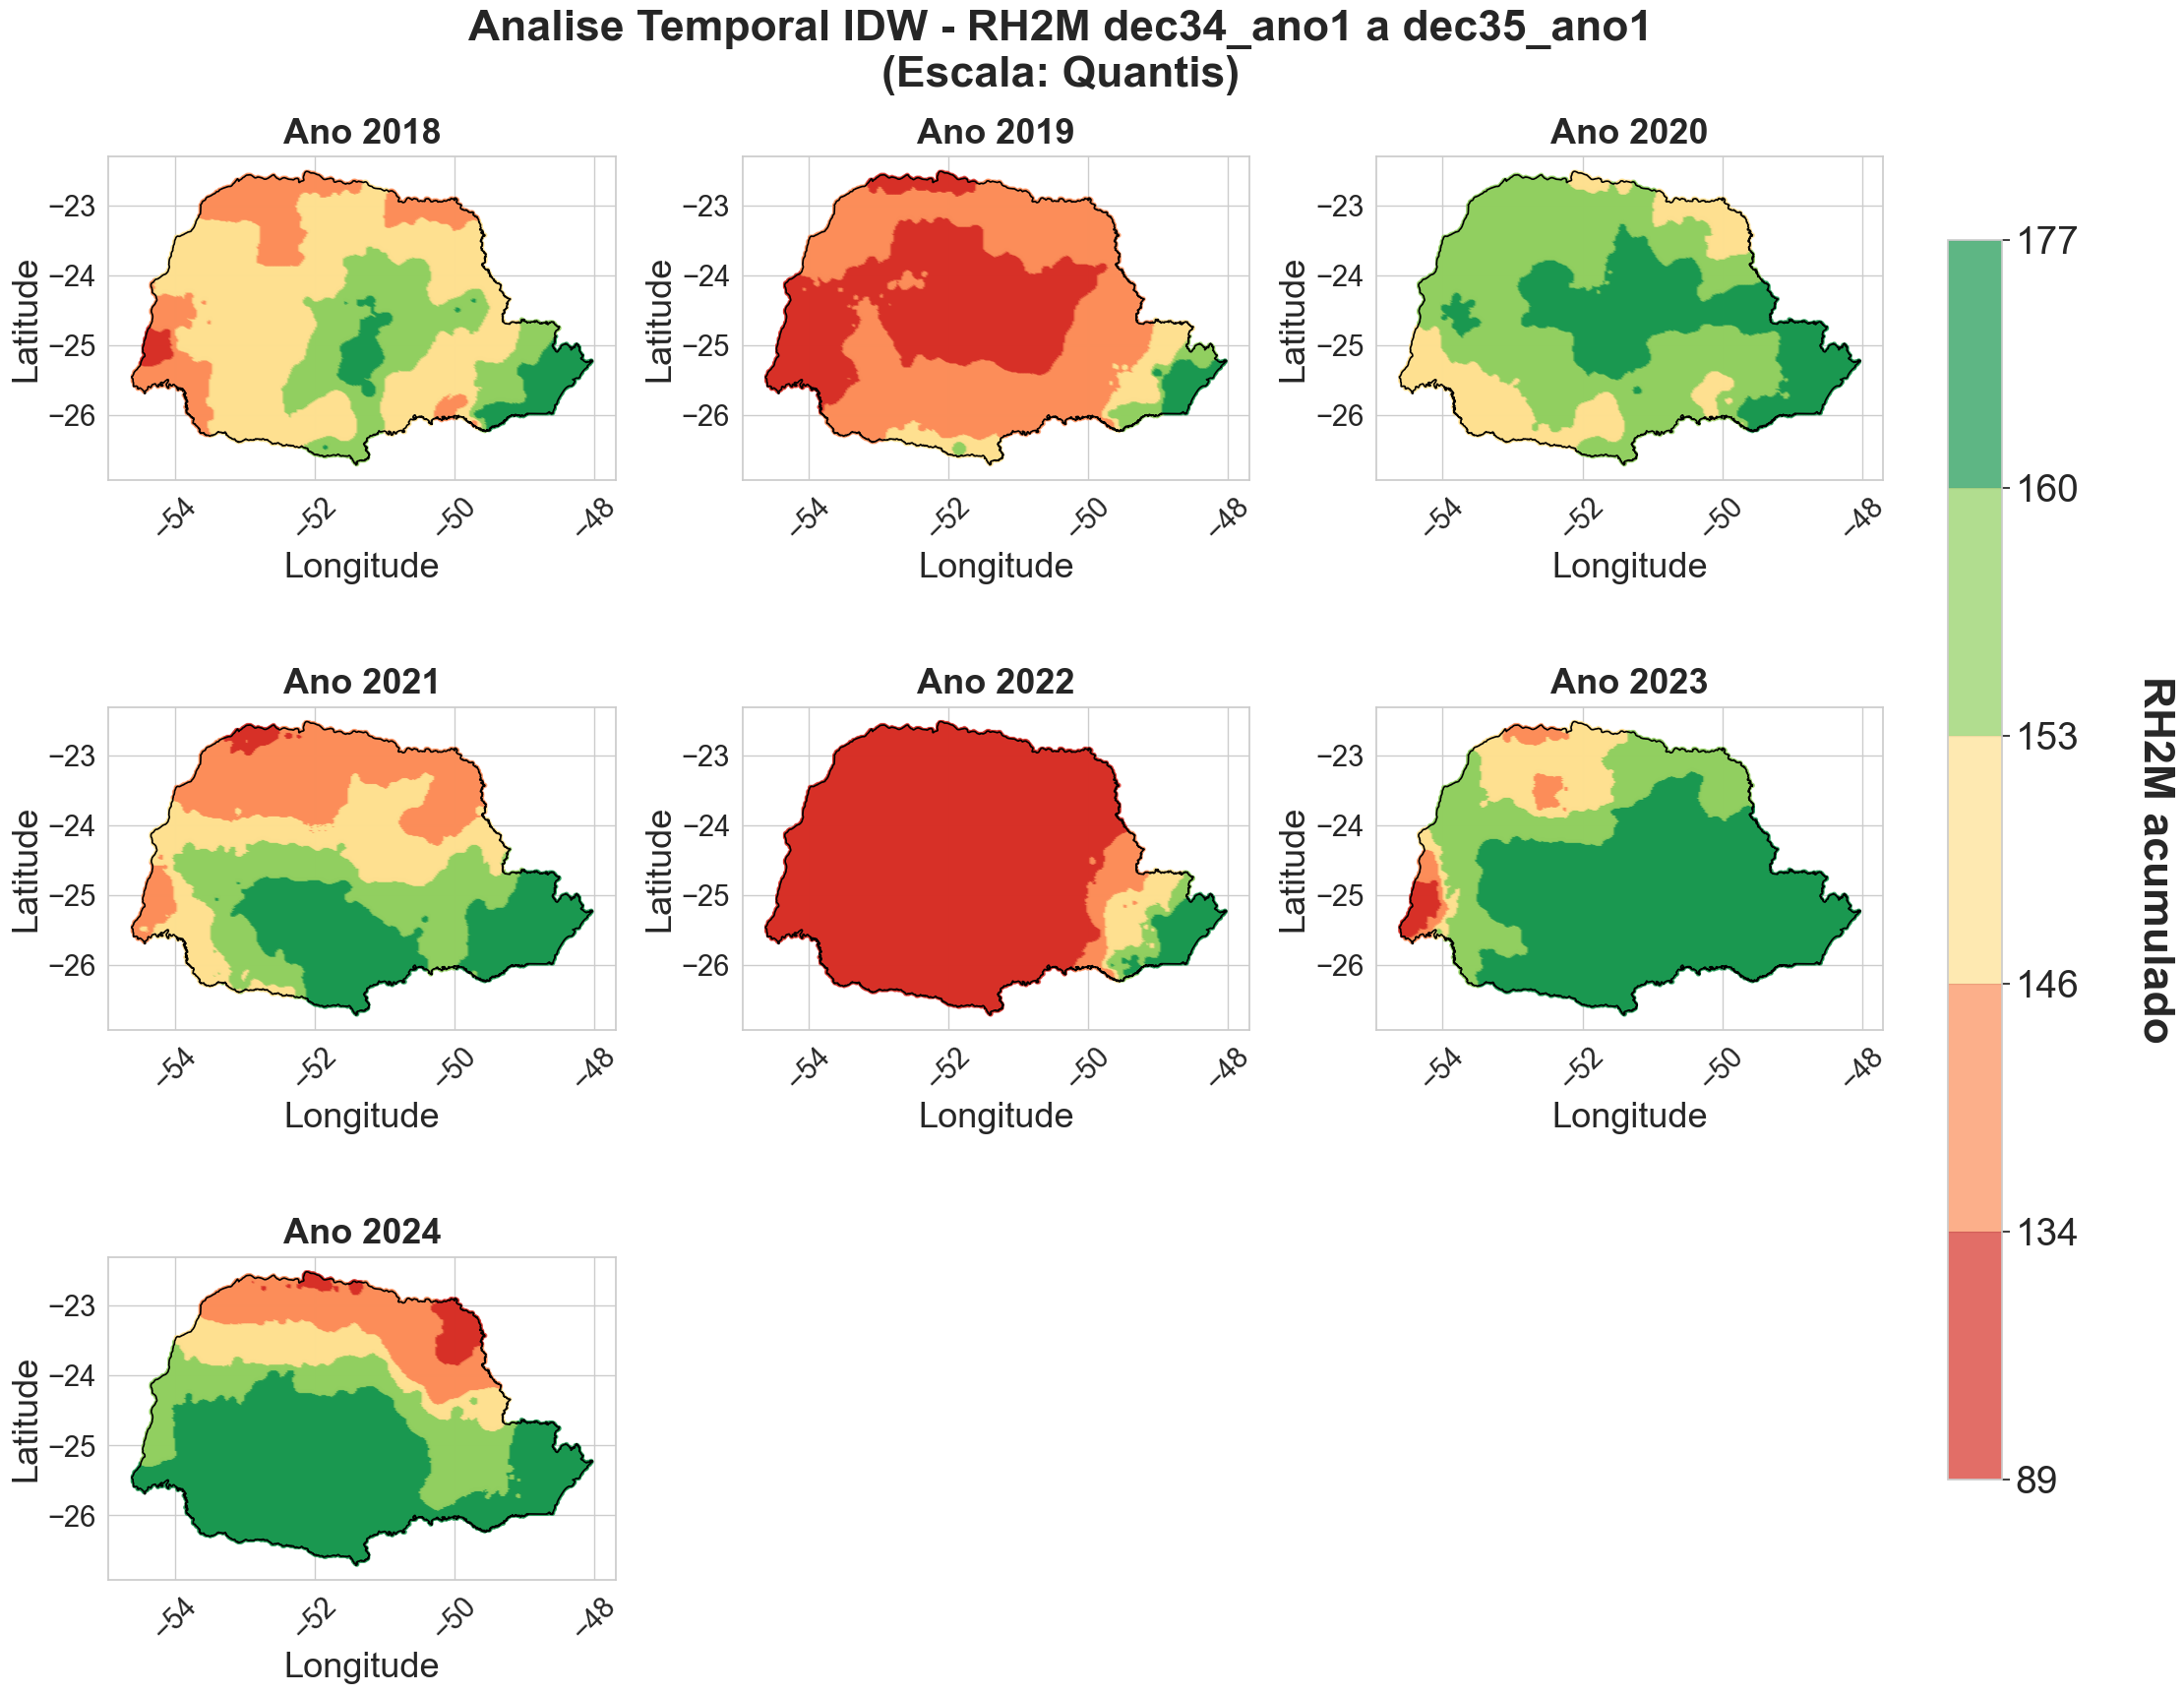

RH2M dec34_ano1 a dec35_ano1 - anos interpolados: [2018, 2019, 2020, 2021, 2022, 2023, 2024]
RH2M dec34_ano1 a dec35_ano1 - municipios por ano: {2018: 399, 2019: 399, 2020: 399, 2021: 399, 2022: 399, 2023: 399, 2024: 399}


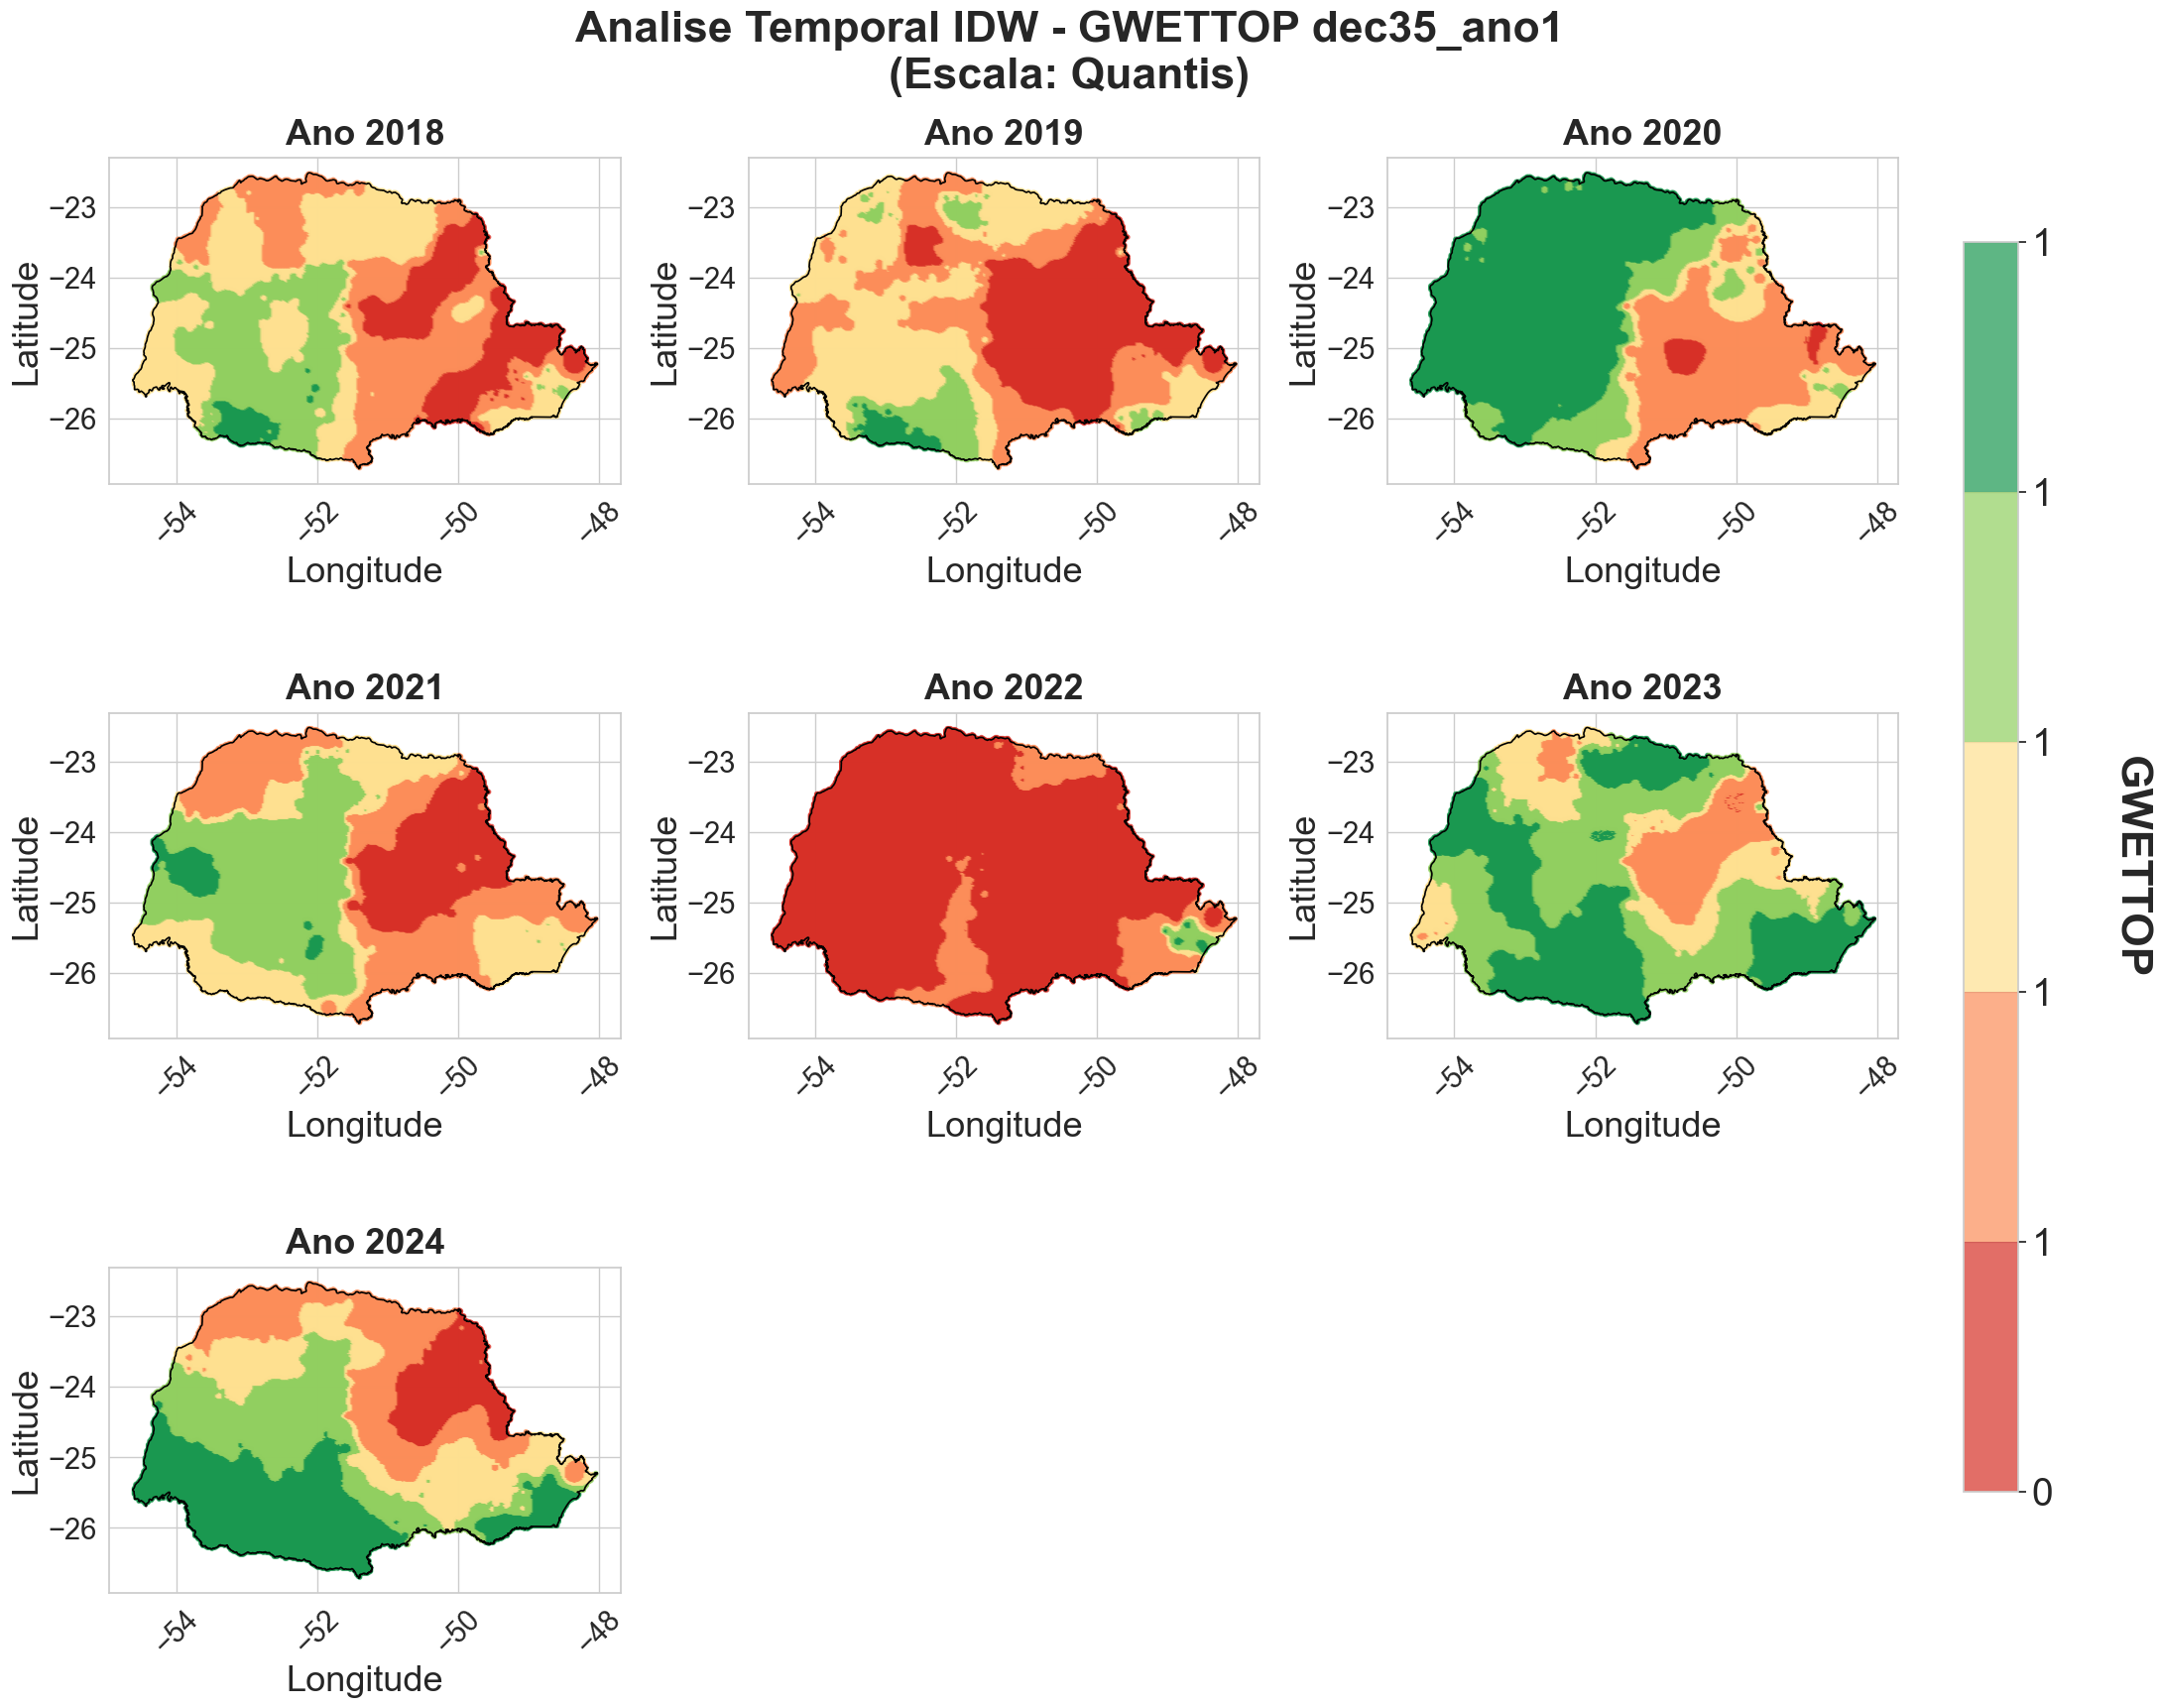

GWETTOP dec35_ano1 - anos interpolados: [2018, 2019, 2020, 2021, 2022, 2023, 2024]
GWETTOP dec35_ano1 - municipios por ano: {2018: 399, 2019: 399, 2020: 399, 2021: 399, 2022: 399, 2023: 399, 2024: 399}


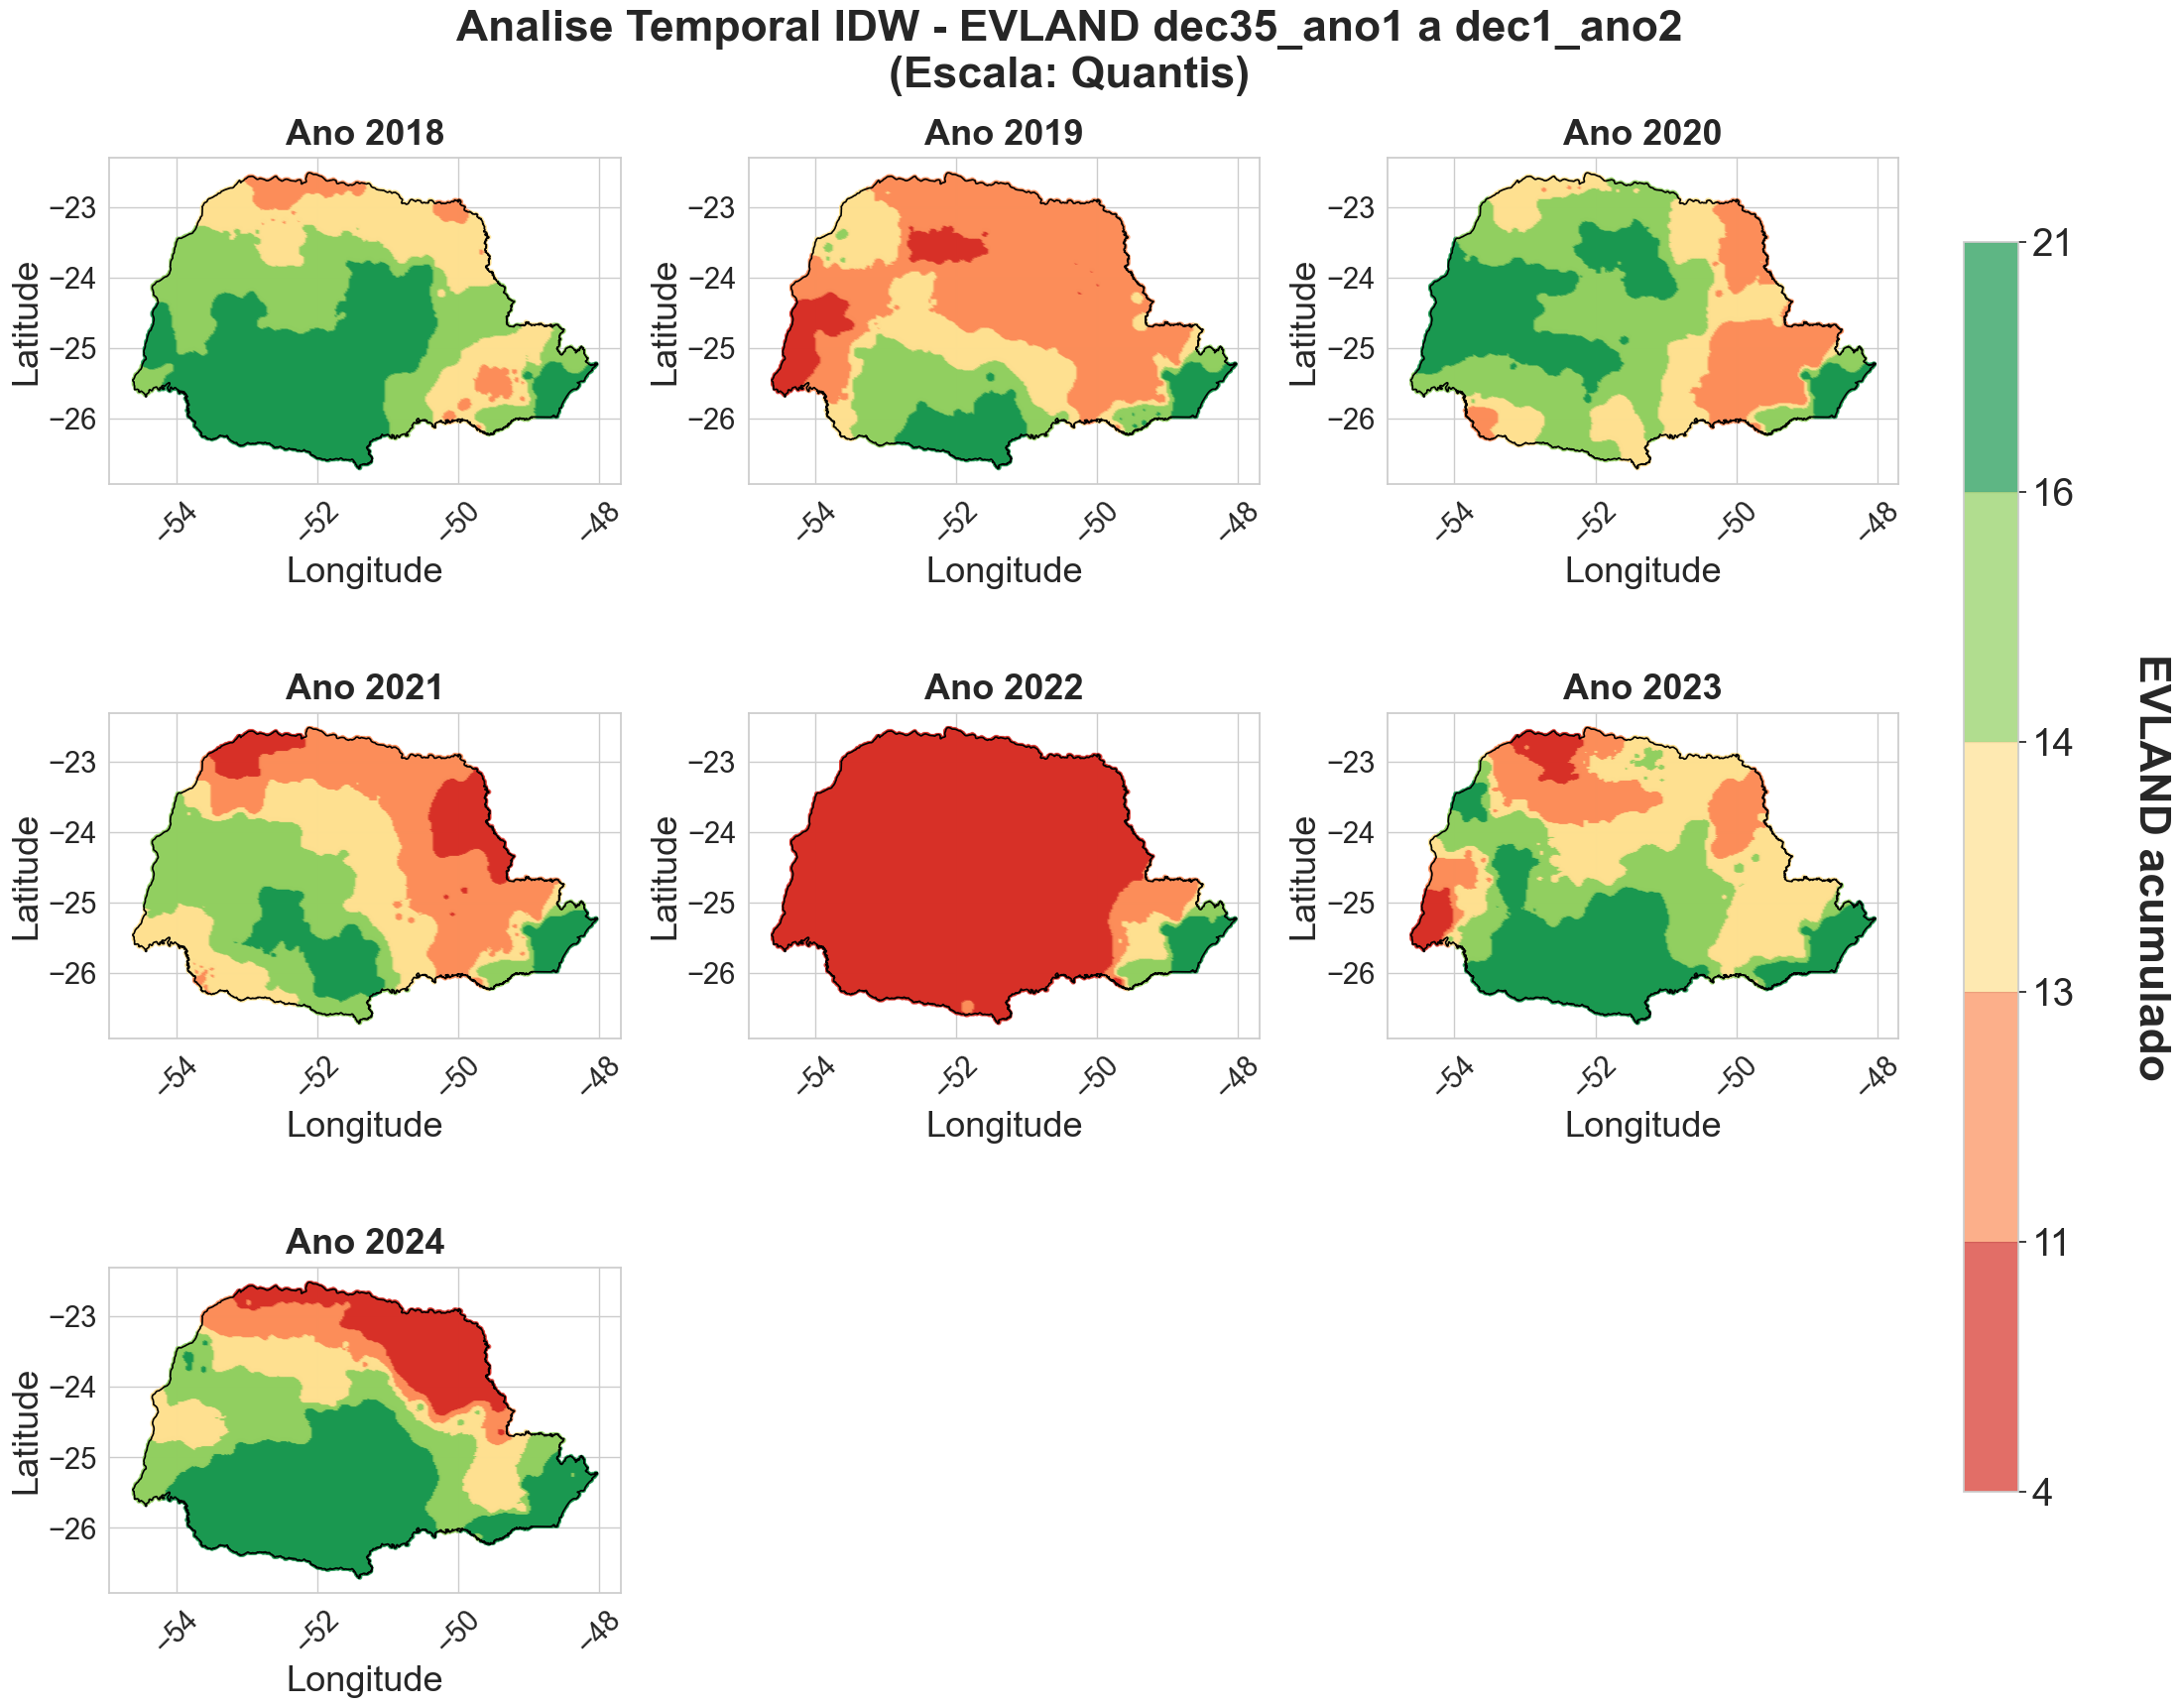

EVLAND dec35_ano1 a dec1_ano2 - anos interpolados: [2018, 2019, 2020, 2021, 2022, 2023, 2024]
EVLAND dec35_ano1 a dec1_ano2 - municipios por ano: {2018: 399, 2019: 399, 2020: 399, 2021: 399, 2022: 399, 2023: 399, 2024: 399}


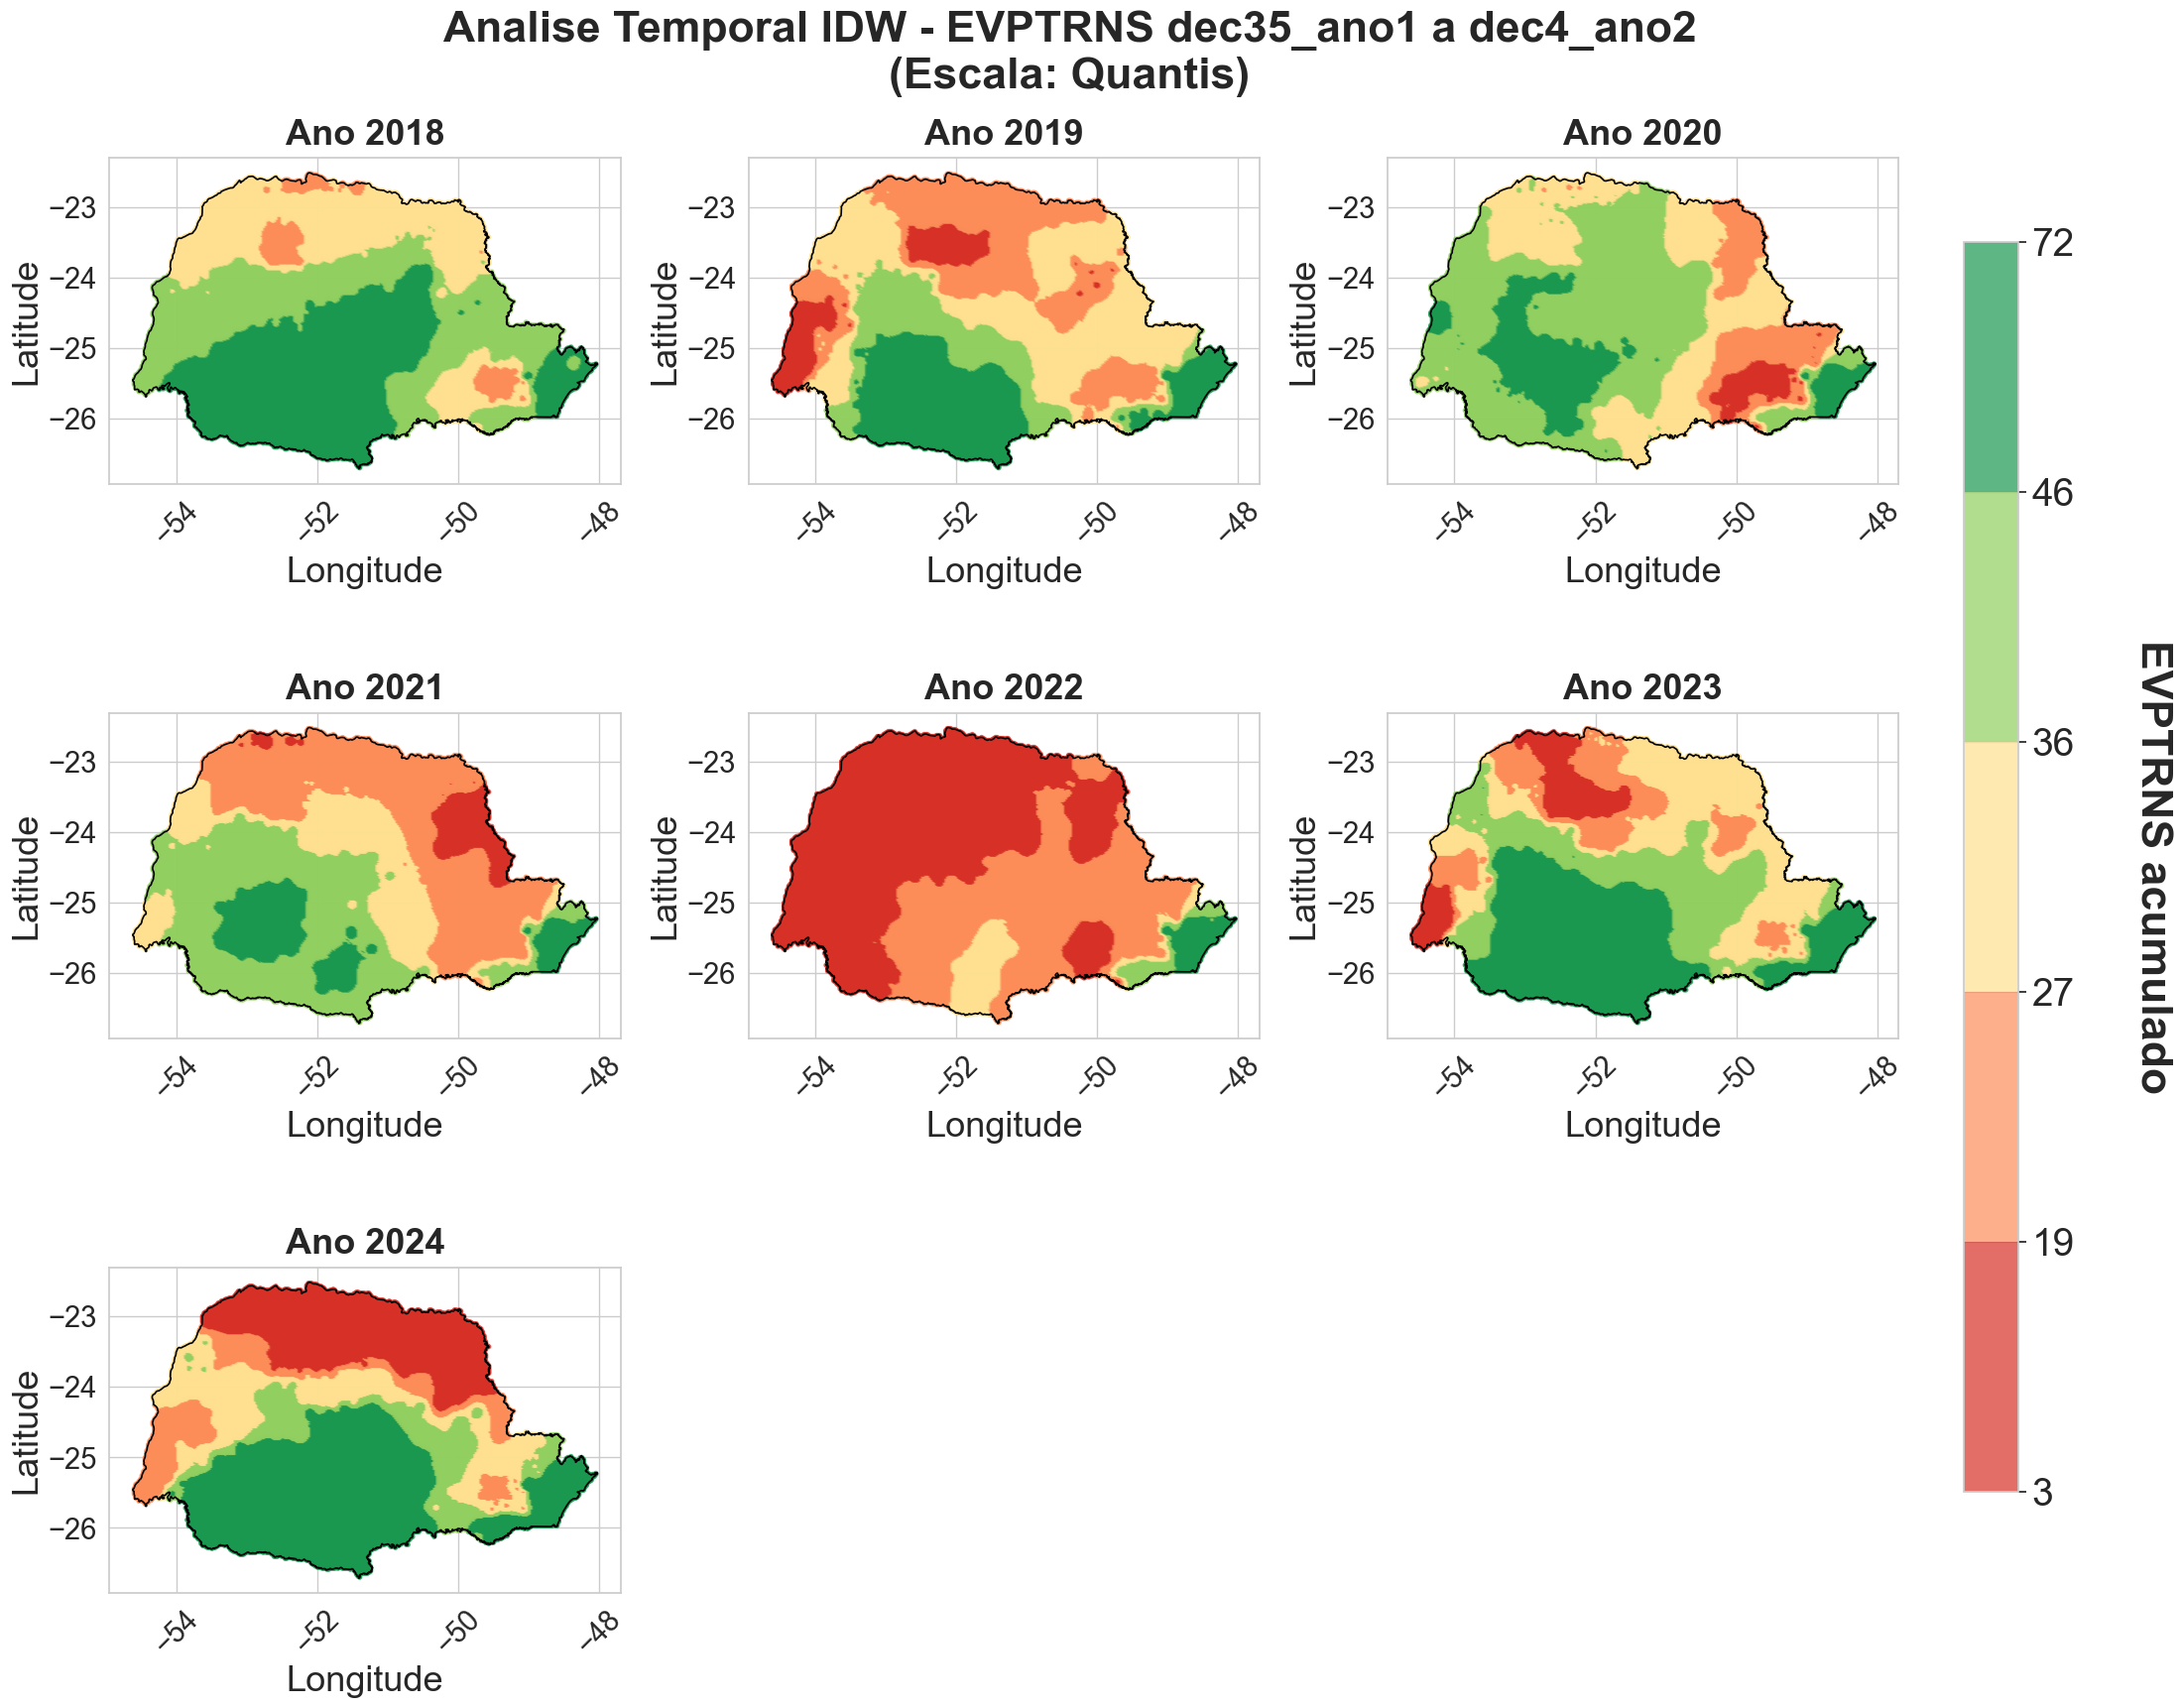

EVPTRNS dec35_ano1 a dec4_ano2 - anos interpolados: [2018, 2019, 2020, 2021, 2022, 2023, 2024]
EVPTRNS dec35_ano1 a dec4_ano2 - municipios por ano: {2018: 399, 2019: 399, 2020: 399, 2021: 399, 2022: 399, 2023: 399, 2024: 399}


In [10]:
# Interpolacao IDW no mesmo padrao de IDW_analise.ipynb
TIPO_ESCALA = 'quantis'  # 'quantis', 'log' ou 'linear'
K_VIZINHOS_IDW = 8
POTENCIA_IDW = 2
RESOLUCAO_GRADE = 300


def idw_interpolation(xy, values, grid_points, k=8, p=2):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', category=RuntimeWarning)
        tree = cKDTree(xy)
        k = min(k, len(xy))
        distances, indices = tree.query(grid_points, k=k)
        if k == 1:
            distances = distances[:, None]
            indices = indices[:, None]
        distances = np.where(distances == 0, 1e-10, distances)
        weights = 1.0 / (distances ** p)
        weights /= weights.sum(axis=1)[:, None]
        return (weights * values[indices]).sum(axis=1)


try:
    estado = read_state(code_state='PR')
    if estado.crs is None:
        estado = estado.set_crs('EPSG:4674')
    origem_poligono = 'geobr.read_state(PR)'
except Exception as exc:
    print(f'Nao foi possivel carregar o poligono do Parana via geobr: {exc}')
    print('Usando contorno aproximado gerado a partir dos pontos municipais.')
    pontos_base = next(iter(dados_por_analise.values())).drop_duplicates(subset='cod_ibge').dropna(subset=['latitude', 'longitude'])
    pontos_estado = gpd.GeoDataFrame(
        pontos_base,
        geometry=gpd.points_from_xy(pontos_base['longitude'], pontos_base['latitude']),
        crs='EPSG:4674'
    )
    estado = gpd.GeoDataFrame(
        {'name_state': ['Parana - contorno aproximado']},
        geometry=[pontos_estado.union_all().convex_hull.buffer(0.25)],
        crs='EPSG:4674'
    )
    origem_poligono = 'contorno aproximado dos municipios'

minx, miny, maxx, maxy = estado.total_bounds
grid_x, grid_y = np.meshgrid(
    np.linspace(minx, maxx, RESOLUCAO_GRADE),
    np.linspace(miny, maxy, RESOLUCAO_GRADE)
)
grid_points = np.vstack([grid_x.ravel(), grid_y.ravel()]).T

grid_points_geom = gpd.GeoSeries([Point(xy) for xy in grid_points], crs=estado.crs)
poligono_pr = estado.union_all()
mask = grid_points_geom.within(poligono_pr)
grid_points = grid_points[mask.values]

print(f'Poligono usado: {origem_poligono}')
print(f'Grade IDW valida: {len(grid_points):,} pontos dentro do Parana')


def plot_idw_temporal(dados, coluna_soma, titulo_variavel, label_barra):
    anos_unicos = sorted(dados['ano'].dropna().astype(int).unique().tolist())
    gdf_cache = {}

    for ano in anos_unicos:
        df_ano = (
            dados.loc[dados['ano'].eq(ano)]
            .copy()
            .drop_duplicates(subset='cod_ibge', keep='first')
            .dropna(subset=['latitude', 'longitude', coluna_soma])
        )
        if df_ano.empty:
            continue

        gdf_pontos = gpd.GeoDataFrame(
            df_ano,
            geometry=gpd.points_from_xy(df_ano['longitude'], df_ano['latitude']),
            crs=estado.crs
        )
        gdf_pontos = gdf_pontos[gdf_pontos.geometry.within(poligono_pr)]
        if not gdf_pontos.empty:
            gdf_cache[ano] = gdf_pontos

    if not gdf_cache:
        raise ValueError(f'Nenhum ponto valido encontrado para {titulo_variavel}.')

    valores_todos = []
    dados_interpolados_por_ano = {}
    anos_com_dados = []

    for ano in anos_unicos:
        if ano not in gdf_cache:
            continue

        gdf_pontos = gdf_cache[ano]
        dados_validos = gdf_pontos[[coluna_soma, 'geometry']].copy()
        dados_validos[coluna_soma] = pd.to_numeric(dados_validos[coluna_soma], errors='coerce')
        dados_validos = dados_validos.dropna(subset=[coluna_soma])
        dados_validos = dados_validos[np.isfinite(dados_validos[coluna_soma])]

        if len(dados_validos) < 3:
            continue

        valores = dados_validos[coluna_soma].to_numpy(dtype=float)
        valores_todos.extend(valores)
        xy = np.vstack((dados_validos.geometry.x, dados_validos.geometry.y)).T
        dados_interpolados_por_ano[ano] = idw_interpolation(
            xy,
            valores,
            grid_points,
            k=K_VIZINHOS_IDW,
            p=POTENCIA_IDW
        )
        anos_com_dados.append(ano)

    if not dados_interpolados_por_ano:
        raise ValueError(f'Nenhum ano com dados suficientes para interpolacao IDW de {titulo_variavel}.')

    valores_todos = np.array(valores_todos, dtype=float)
    valores_positivos = valores_todos[valores_todos > 0]
    if len(valores_positivos) == 0:
        raise ValueError(f'Nenhum valor positivo encontrado para escala do mapa de {titulo_variavel}.')

    if TIPO_ESCALA == 'quantis':
        limites = np.unique(np.percentile(valores_positivos, [0, 20, 40, 60, 80, 100]))
    elif TIPO_ESCALA == 'log':
        limites = np.logspace(
            np.log10(np.nanmin(valores_positivos)),
            np.log10(np.nanmax(valores_positivos)),
            6
        )
    else:
        limites = np.linspace(np.nanmin(valores_positivos), np.nanmax(valores_positivos), 6)

    if len(limites) < 2:
        limites = np.linspace(np.nanmin(valores_positivos), np.nanmax(valores_positivos) + 1, 6)

    cores = ['#d73027', '#fc8d59', '#fee090', '#91cf60', '#1a9850']
    cmap = ListedColormap(cores)
    norm = BoundaryNorm(limites, cmap.N)

    fig, axes = plt.subplots(3, 3, figsize=(22, 18), squeeze=False)
    axes_flat = axes.flatten()
    sc_ref = None

    for i, ano in enumerate(anos_unicos):
        ax = axes_flat[i]
        if ano not in dados_interpolados_por_ano:
            ax.set_visible(False)
            continue

        sc = ax.scatter(
            grid_points[:, 0],
            grid_points[:, 1],
            c=dados_interpolados_por_ano[ano],
            cmap=cmap,
            norm=norm,
            alpha=0.7,
            s=8
        )
        if sc_ref is None:
            sc_ref = sc

        estado.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.2)
        ax.set_title(f'Ano {ano}', fontsize=26, fontweight='bold', pad=10)
        ax.set_xlabel('Longitude', fontsize=26)
        ax.set_ylabel('Latitude', fontsize=26)
        ax.tick_params(axis='x', labelsize=21, rotation=45, pad=3)
        ax.tick_params(axis='y', labelsize=21, pad=3)
        ax.set_aspect('equal', adjustable='box')

    for j in range(len(anos_unicos), len(axes_flat)):
        axes_flat[j].set_visible(False)

    escala_texto = {'quantis': 'Quantis', 'log': 'Logaritmica', 'linear': 'Linear'}
    fig.suptitle(
        f'Analise Temporal IDW - {titulo_variavel}\n(Escala: {escala_texto[TIPO_ESCALA]})',
        fontsize=32,
        fontweight='bold',
        y=0.98
    )
    fig.subplots_adjust(top=0.93, bottom=0.06, left=0.06, right=0.88, hspace=0.25, wspace=0.25)

    if sc_ref is not None:
        cbar_ax = fig.add_axes([0.91, 0.15, 0.025, 0.7])
        fmt = '%.0e' if TIPO_ESCALA == 'log' else '%.0f'
        cbar = fig.colorbar(sc_ref, cax=cbar_ax, boundaries=limites, ticks=limites, format=fmt)
        cbar.set_label(label_barra, rotation=270, labelpad=70, fontsize=32, fontweight='bold')
        cbar.ax.tick_params(labelsize=28)

    plt.show()

    print(f'{titulo_variavel} - anos interpolados: {anos_com_dados}')
    print(f'{titulo_variavel} - municipios por ano: { {ano: len(gdf_cache[ano]) for ano in anos_com_dados} }')


for analise in ANALISES_IDW:
    plot_idw_temporal(
        dados_por_analise[analise['nome']],
        analise['coluna_soma'],
        f"{analise['nome']} {analise['janela']}",
        analise['label_barra']
    )
